<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/28Maret2026/Ai_ml_pengantar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
# Data sederhana: jam belajar -> nilai
data = { "jam_belajar": [2, 4, 6, 8, 10], "nilai": [60, 68, 76, 85, 93] }

In [3]:
df = pd.DataFrame(data)

In [4]:
X = df[["jam_belajar"]]
y = df["nilai"]

In [5]:
model = LinearRegression()

In [6]:
model.fit(X, y)

LinearRegression()

In [7]:
prediksi = model.predict([[7]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
print("Koefisien :", model.coef_[0])
print("Intercept :", model.intercept_)
print("Prediksi nilai untuk 7 jam belajar:", prediksi[0])

Koefisien : 4.15
Intercept : 51.5
Prediksi nilai untuk 7 jam belajar: 80.55000000000001


In [9]:
import pandas as pd
from sklearn.cluster import KMeans

In [10]:
# Unsupervised learning: tidak ada target

In [11]:
df = pd.DataFrame({ "belanja_bulanan": [1, 2, 2, 8, 9, 10], "frekuensi_kunjungan": [1, 1, 2, 8, 9, 10] })

In [12]:
X = df[["belanja_bulanan", "frekuensi_kunjungan"]]

In [13]:
model = KMeans(n_clusters=2, random_state=42, n_init=10)

In [14]:
df["cluster"] = model.fit_predict(X)

In [15]:
print(df)

   belanja_bulanan  frekuensi_kunjungan  cluster
0                1                    1        0
1                2                    1        0
2                2                    2        0
3                8                    8        1
4                9                    9        1
5               10                   10        1


In [17]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [20]:
df = pd.DataFrame({ "jam_belajar": [2, 4, 6, 8, 10], "nilai": [60, 68, 76, 85, 93] })
X = df[["jam_belajar"]]
y = df["nilai"]

In [22]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [23]:
print("Prediksi nilai untuk 7 jam belajar:", model.predict([[7]])[0])

Prediksi nilai untuk 7 jam belajar: 80.55000000000001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [25]:
df = pd.DataFrame({ "jam_belajar": [2, 3, 4, 7, 8, 9], "lulus": [0, 0, 0, 1, 1, 1] })

In [27]:
X = df[["jam_belajar"]]
y = df["lulus"]

In [29]:
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [30]:
prediksi_kelas = model.predict([[6]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [31]:
prediksi_prob = model.predict_proba([[6]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [32]:
print("Prediksi kelas untuk 6 jam belajar:", prediksi_kelas)
print("Probabilitas [tidak lulus, lulus]:", prediksi_prob)

Prediksi kelas untuk 6 jam belajar: 1
Probabilitas [tidak lulus, lulus]: [0.37265346 0.62734654]


**Materi Underfitting dan overfitting**

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

In [34]:
# Data sederhana

In [35]:
np.random.seed(42)

In [36]:
X = np.linspace(0, 10, 20).reshape(-1, 1)
y = 3 * X.squeeze() + 10 + np.random.normal(0, 2, size=20)

In [37]:
# Model terlalu sederhana (underfit untuk data non-linear; di sini contoh konsep)

In [38]:
model_linear = LinearRegression()
model_linear.fit(X, y)

LinearRegression()

In [39]:
# Model terlalu kompleks (potensi overfit)

In [40]:
model_poly = make_pipeline(PolynomialFeatures(degree=10), LinearRegression())

In [41]:
model_poly.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=10)),
                ('linearregression', LinearRegression())])

In [44]:
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_linear = model_linear.predict(X_plot)
y_poly = model_poly.predict(X_plot)

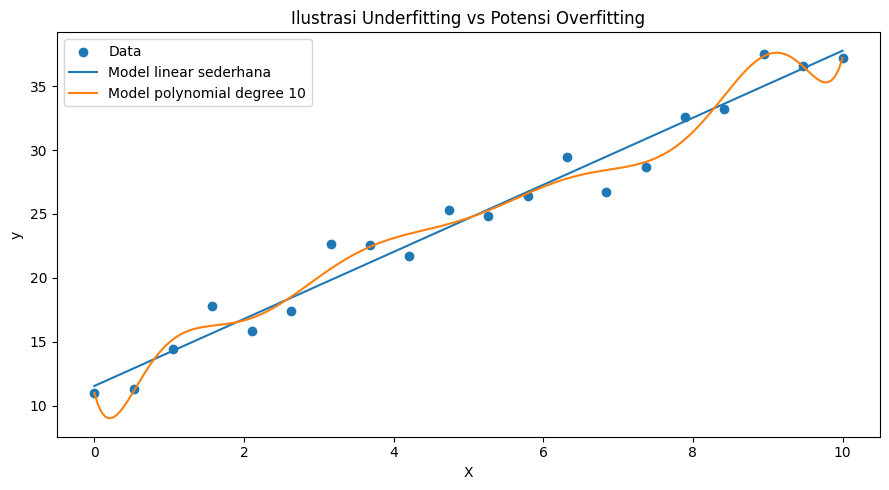

In [45]:
plt.figure(figsize=(9, 5))
plt.scatter(X, y, label="Data")
plt.plot(X_plot, y_linear, label="Model linear sederhana")
plt.plot(X_plot, y_poly, label="Model polynomial degree 10")
plt.title("Ilustrasi Underfitting vs Potensi Overfitting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()